# Bài tập Lập trình 2: Phân tích Quan điểm Sinh viên (UIT-VSFC)

**Phương pháp đề xuất:** Multi-task Bi-LSTM + Masked Attention Mechanism + Pre-trained Embeddings

**Các điểm cải tiến (Novelty & Optimizations) so với Baseline:**
1. **Multi-task Learning:** Tận dụng sự tương quan giữa Chủ đề và Cảm xúc, mô hình học đồng thời 2 tác vụ thông qua một lớp biểu diễn dùng chung (Bi-LSTM).
2. **Masked Attention Module:** Cải tiến cơ chế Attention bằng cách thêm **Masking**. Mô hình sẽ bỏ qua các token `<pad>` (padding), giúp tập trung 100% vào các từ khóa thực sự (khắc phục điểm yếu chí mạng của Attention thông thường).
3. **Pre-trained Embeddings:** Khởi tạo vector từ bằng mô hình FastText/Word2Vec tiếng Việt (có cơ chế fallback nều không tìm thấy file).
4. **Class Weights:** Xử lý bài toán mất cân bằng dữ liệu quá mức (nhãn Neutral chỉ có 4%, nhãn Lecturer chiếm 71%).
5. **Xử lý ngôn ngữ Tiếng Việt:** Sử dụng `pyvi` tối ưu hóa và chuẩn hóa biểu tượng cảm xúc (emoticons) dựa trên đặc tả của dataset.

In [1]:
#!pip install pyvi torch torchvision torchaudio scikit-learn matplotlib seaborn numpy pandas tqdm

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import classification_report, f1_score, confusion_matrix
from pyvi import ViTokenizer

# Thiết lập Device (Ưu tiên dùng GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Đang sử dụng thiết bị: {device}")

# Cố định random seed
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

[INFO] Đang sử dụng thiết bị: cpu


## 1. Tiền xử lý dữ liệu (Data Preprocessing)

In [3]:
DATA_DIR = "UIT-VSFC/"

# Từ điển ánh xạ Emoticon dựa trên hướng dẫn trong README.txt
EMOTICON_DICT = {
    ":)": "colonsmile", ":(": "colonsad", "@@": "colonsurprise", 
    "<3": "colonlove", ":d": "colonsmilesmile", ":3": "coloncontemn", 
    ":v": "colonbigsmile", ":_": "coloncc", ":p": "colonsmallsmile", 
    ">>": "coloncolon", ":\">": "colonlovelove", "^^": "colonhihi", 
    ":'": "colonsadcolon", ":’(": "colonsadcolon", ":@": "colondoublesurprise", 
    "v.v": "vdotv", "...": "dotdotdot"
}

def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    
    # Ánh xạ các biểu tượng cảm xúc
    for k, v in EMOTICON_DICT.items():
        text = text.replace(k, f" {v} ")
    
    # Tách từ tiếng Việt bằng thư viện pyvi
    text = ViTokenizer.tokenize(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_dataset(split_name):
    path = os.path.join(DATA_DIR, split_name)
    
    # Đọc các file
    with open(os.path.join(path, "sents.txt"), "r", encoding="utf-8") as f:
        sents = [clean_text(line) for line in f.readlines()]
    with open(os.path.join(path, "sentiments.txt"), "r", encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f.readlines()]
    with open(os.path.join(path, "topics.txt"), "r", encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f.readlines()]
        
    return pd.DataFrame({"text": sents, "sentiment": sentiments, "topic": topics})

# Tải dữ liệu thực tế
try:
    print("Đang tiền xử lý dữ liệu (Word Segmentation)... Vui lòng đợi.")
    train_df = load_dataset("train")
    dev_df = load_dataset("dev")
    test_df = load_dataset("test")
    print(f"[SUCCESS] Load thành công. Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
except Exception as e:
    print("[LỖI] Không tìm thấy dữ liệu. Đảm bảo bạn đã tải lên folder 'Project 2/UIT-VSFC/'")
    print("Chi tiết lỗi:", e)

Đang tiền xử lý dữ liệu (Word Segmentation)... Vui lòng đợi.
[SUCCESS] Load thành công. Train: 11426 | Dev: 1583 | Test: 3166


### 🔍 Insight 1: Đặc điểm Dữ liệu & Tiền xử lý

**Phân bố nhãn mất cân bằng nghiêm trọng:**
- **Sentiment:** Nhãn `Neutral` chỉ chiếm ~4% tổng mẫu, trong khi `Positive` và `Negative` chiếm phần lớn. Đây là thách thức điển hình trong phân loại cảm xúc thực tế — sinh viên hiếm khi bày tỏ cảm xúc trung lập một cách rõ ràng.
- **Topic:** Nhãn `Lecturer` chiếm tới ~71%, phản ánh xu hướng sinh viên Việt Nam thường bình luận về giảng viên nhiều hơn so với cơ sở vật chất hay chương trình học.

**Quyết định kỹ thuật tiền xử lý:**
- Việc **ánh xạ emoticon** (`:)` → `colonsmile`) rất quan trọng vì dataset UIT-VSFC thu thập từ phản hồi sinh viên thực tế — nơi emoticon mang tải ngữ nghĩa cảm xúc cao.
- **`ViTokenizer` (pyvi)** giúp phân đoạn từ tiếng Việt đúng (vd: `sinh viên` là 1 đơn vị ngữ nghĩa, không phải 2 token riêng lẻ). Đây là bước không thể thiếu vì tiếng Việt không dùng khoảng trắng để phân tách từ như tiếng Anh.
- `MAX_LEN = 30` bao phủ hơn 90% câu trong dataset, là điểm cân bằng hợp lý giữa bộ nhớ và độ bao phủ thông tin.


## 2. Xây dựng Từ điển (Vocabulary) & Embeddings

In [4]:
class Vocab:
    def __init__(self, min_freq=2):
        self.w2i = {"<pad>": 0, "<unk>": 1}
        self.i2w = {0: "<pad>", 1: "<unk>"}
        self.min_freq = min_freq
        
    def build(self, sentences):
        word_counts = Counter()
        for sent in sentences:
            word_counts.update(sent.split())
            
        for word, count in word_counts.items():
            if count >= self.min_freq:
                idx = len(self.w2i)
                self.w2i[word] = idx
                self.i2w[idx] = word
                
    def encode(self, sent, max_len):
        tokens = sent.split()
        indices = [self.w2i.get(w, self.w2i["<unk>"]) for w in tokens[:max_len]]
        if len(indices) < max_len:
            indices += [self.w2i["<pad>"]] * (max_len - len(indices))
        return indices

MAX_LEN = 30  # Chiếm hơn 90% độ dài câu theo phân tích của bài báo
vocab = Vocab(min_freq=2)
vocab.build(train_df['text'].tolist())
print(f"Kích thước bộ từ vựng: {len(vocab.w2i)} words")

def load_pretrained_embeddings(vocab, embed_dim=300, filepath="cc.vi.300.vec"):
    # Khởi tạo ma trận ngẫu nhiên
    embedding_matrix = np.random.normal(scale=0.6, size=(len(vocab.w2i), embed_dim))
    embedding_matrix[0] = np.zeros(embed_dim) # Token <pad> luôn có vector 0
    
    loaded_words = 0
    if os.path.exists(filepath):
        print(f"[INFO] Đang load FastText weights từ {filepath}...")
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.rstrip().split(' ')
                word = values[0]
                if word in vocab.w2i:
                    embedding_matrix[vocab.w2i[word]] = np.array(values[1:], dtype='float32')
                    loaded_words += 1
        print(f"[SUCCESS] Đã load {loaded_words}/{len(vocab.w2i)} từ từ FastText.")
    else:
        print(f"[INFO] Không tìm thấy file {filepath}. Mô hình sẽ train Embeddings từ đầu (Random Init).")
        
    return torch.tensor(embedding_matrix, dtype=torch.float32)

EMBED_DIM = 300
pretrained_weights = load_pretrained_embeddings(vocab, embed_dim=EMBED_DIM)

Kích thước bộ từ vựng: 2069 words
[INFO] Đang load FastText weights từ cc.vi.300.vec...
[SUCCESS] Đã load 1008/2069 từ từ FastText.


### 🔍 Insight 2: Chiến lược Embedding & Từ điển

- **`min_freq=2`:** Lọc các từ xuất hiện chỉ 1 lần giúp giảm noise và kích thước từ điển, tránh mô hình học các pattern nhiễu từ từ hiếm.
- **FastText với cơ chế fallback:** Sử dụng pre-trained FastText tiếng Việt (`cc.vi.300.vec`) giúp mô hình khởi đầu với ngữ nghĩa phong phú. Khi không có file, mô hình vẫn hoạt động được nhờ random initialization — thiết kế robust phù hợp môi trường thực tế.
- **Fine-tuning embeddings (`requires_grad=True`):** Thay vì đóng băng weights pre-trained, mô hình cho phép tinh chỉnh nhẹ để thích nghi với ngôn ngữ đặc thù của sinh viên (từ lóng, cách viết tắt, v.v.).


In [5]:
class UITDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.df = df
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text_encoded = self.vocab.encode(row['text'], self.max_len)
        return {
            'input_ids': torch.tensor(text_encoded, dtype=torch.long),
            'sentiment': torch.tensor(row['sentiment'], dtype=torch.long),
            'topic': torch.tensor(row['topic'], dtype=torch.long)
        }

BATCH_SIZE = 64
train_loader = DataLoader(UITDataset(train_df, vocab, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(UITDataset(dev_df, vocab, MAX_LEN), batch_size=BATCH_SIZE)
test_loader = DataLoader(UITDataset(test_df, vocab, MAX_LEN), batch_size=BATCH_SIZE)

## 3. Kiến trúc Mô hình: Masked Attention Bi-LSTM
*(Điểm mới: Cải tiến Attention module để nhận diện và loại bỏ padding tokens)*

In [6]:
class MaskedAttention(nn.Module):
    """Module Attention CÓ XỬ LÝ MASKING để bỏ qua các token <pad>"""
    def __init__(self, hidden_dim):
        super(MaskedAttention, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, lstm_outputs, mask):
        # lstm_outputs: [batch_size, seq_len, hidden_dim]
        # mask: [batch_size, seq_len]
        
        energy = self.attention(lstm_outputs).squeeze(-1) # [batch_size, seq_len]
        
        # Gán trọng số của các token <pad> (nơi mask == 0) thành số âm rất nhỏ (-1e9)
        # Để khi qua Softmax, trọng số của nó sẽ biến thành 0
        energy = energy.masked_fill(mask == 0, -1e9)
        
        attn_weights = F.softmax(energy, dim=1).unsqueeze(-1) # [batch_size, seq_len, 1]
        context_vector = torch.sum(attn_weights * lstm_outputs, dim=1) # [batch_size, hidden_dim]
        return context_vector, attn_weights


class MultiTaskModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pretrained_matrix=None, num_sentiments=3, num_topics=4):
        super(MultiTaskModel, self).__init__()
        
        # 1. Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_matrix is not None:
            self.embedding.weight.data.copy_(pretrained_matrix)
            # Cho phép tinh chỉnh (fine-tune) nhẹ các word vectors
            self.embedding.weight.requires_grad = True 
            
        self.dropout = nn.Dropout(0.4)
        
        # 2. Bi-LSTM
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, 
                            bidirectional=True, batch_first=True, dropout=0.3)
        
        # 3. Masked Attention
        self.attention = MaskedAttention(hidden_dim * 2)
        
        # 4. Multi-task Heads
        self.fc_sentiment = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_sentiments)
        )
        
        self.fc_topic = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_topics)
        )

    def forward(self, input_ids):
        # Tạo mask: 1 nếu là từ thực sự, 0 nếu là <pad>
        mask = (input_ids != 0) 
        
        embeds = self.dropout(self.embedding(input_ids))
        lstm_out, _ = self.lstm(embeds)
        
        # Đưa vào Attention có kèm Mask
        context, _ = self.attention(lstm_out, mask)
        
        out_sent = self.fc_sentiment(context)
        out_topic = self.fc_topic(context)
        return out_sent, out_topic

### 🔍 Insight 3: Phân tích Kiến trúc Mô hình

**Tại sao Multi-task Learning hiệu quả hơn 2 mô hình riêng lẻ?**
Chủ đề (`topic`) và cảm xúc (`sentiment`) có sự tương quan chặt chẽ — ví dụ, phàn nàn về `Facility` thường đi kèm `Negative`. Chia sẻ lớp Bi-LSTM giúp hai tác vụ *điều chỉnh lẫn nhau*, giảm overfitting và cải thiện khả năng tổng quát hóa.

**Tại sao cần Masked Attention?**
- Attention thông thường phân phối trọng số cho **tất cả** token kể cả `<pad>`, làm loãng tín hiệu từ các từ có nghĩa thực sự.
- `masked_fill(mask == 0, -1e9)` đảm bảo các token padding có trọng số ≈ 0 sau Softmax, giúp mô hình **tập trung 100% vào nội dung thực**.
- Cải tiến này đặc biệt quan trọng với dataset ngắn (MAX_LEN=30) vì tỷ lệ padding cao ở các câu ngắn.

**Bi-LSTM 2 lớp + Dropout:**
- Bi-LSTM nắm bắt ngữ cảnh **hai chiều** — quan trọng với tiếng Việt nơi ý nghĩa phụ thuộc vào cả từ đứng trước lẫn sau.
- `LayerNorm` + `Dropout(0.3/0.4)` trong các đầu phân loại giúp ổn định huấn luyện và giảm overfitting.


## 4. Xử lý Class Weights & Huấn luyện (Training Loop)

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Phạt nặng mô hình khi đoán sai các class thiểu số (Neutral, Facility)
sent_w = compute_class_weight('balanced', classes=np.unique(train_df['sentiment']), y=train_df['sentiment'])
topic_w = compute_class_weight('balanced', classes=np.unique(train_df['topic']), y=train_df['topic'])

sent_weights = torch.tensor(sent_w, dtype=torch.float).to(device)
topic_weights = torch.tensor(topic_w, dtype=torch.float).to(device)

HIDDEN_DIM = 128
model = MultiTaskModel(len(vocab.w2i), EMBED_DIM, HIDDEN_DIM, pretrained_matrix=pretrained_weights).to(device)

criterion_sentiment = nn.CrossEntropyLoss(weight=sent_weights)
criterion_topic = nn.CrossEntropyLoss(weight=topic_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

In [8]:
def evaluate(model, dataloader):
    model.eval()
    sent_preds, sent_trues, topic_preds, topic_trues = [], [], [], []
    total_loss = 0
    ALPHA = 0.5 
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            sentiments = batch['sentiment'].to(device)
            topics = batch['topic'].to(device)
            
            out_sent, out_topic = model(input_ids)
            
            loss_sent = criterion_sentiment(out_sent, sentiments)
            loss_topic = criterion_topic(out_topic, topics)
            loss = ALPHA * loss_sent + (1 - ALPHA) * loss_topic
            total_loss += loss.item()
            
            sent_preds.extend(torch.argmax(out_sent, dim=1).cpu().numpy())
            sent_trues.extend(sentiments.cpu().numpy())
            topic_preds.extend(torch.argmax(out_topic, dim=1).cpu().numpy())
            topic_trues.extend(topics.cpu().numpy())
            
    # Tính F1-score Macro (để so sánh với baseline bài báo)
    sent_f1 = f1_score(sent_trues, sent_preds, average='macro')
    topic_f1 = f1_score(topic_trues, topic_preds, average='macro')
    
    return total_loss / len(dataloader), sent_f1, topic_f1, (sent_preds, sent_trues, topic_preds, topic_trues)

EPOCHS = 15
best_val_f1 = 0
patience_counter = 0
EARLY_STOP_PATIENCE = 4

history = {'train_loss': [], 'val_loss': [], 'val_sent_f1': [], 'val_topic_f1': []}
ALPHA = 0.5  # Trọng số cân bằng 2 hàm loss

print("Bắt đầu huấn luyện mô hình...")
for epoch in range(EPOCHS):
    model.train()
    train_loss, tr_loss_sent, tr_loss_topic = 0, 0, 0
    
    # Sử dụng TQDM cho thanh tiến trình
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False)
    for batch in progress_bar:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        sentiments = batch['sentiment'].to(device)
        topics = batch['topic'].to(device)
        
        out_sent, out_topic = model(input_ids)
        
        loss_sent = criterion_sentiment(out_sent, sentiments)
        loss_topic = criterion_topic(out_topic, topics)
        loss = ALPHA * loss_sent + (1 - ALPHA) * loss_topic
        
        loss.backward()
        # Gradient Clipping chống Exploding Gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        tr_loss_sent += loss_sent.item()
        tr_loss_topic += loss_topic.item()
        
        progress_bar.set_postfix({'loss': loss.item()})
        
    train_loss /= len(train_loader)
    val_loss, val_sent_f1, val_topic_f1, _ = evaluate(model, dev_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_sent_f1'].append(val_sent_f1)
    history['val_topic_f1'].append(val_topic_f1)
    
    avg_val_f1 = (val_sent_f1 + val_topic_f1) / 2
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Sent Macro-F1: {val_sent_f1:.4f} | Topic Macro-F1: {val_topic_f1:.4f}")
    
    scheduler.step(avg_val_f1)
    
    if avg_val_f1 > best_val_f1:
        best_val_f1 = avg_val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print("\n[INFO] Dừng sớm (Early Stopping) để tránh Overfitting!")
            break

Bắt đầu huấn luyện mô hình...


Epoch 1/15:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.8182 | Val Loss: 0.6496 | Sent Macro-F1: 0.6445 | Topic Macro-F1: 0.6857


Epoch 2/15:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.5721 | Val Loss: 0.6071 | Sent Macro-F1: 0.7181 | Topic Macro-F1: 0.7160


...

Epoch 11 | Train Loss: 0.2151 | Val Loss: 0.7951 | Sent Macro-F1: 0.7851 | Topic Macro-F1: 0.7006


Epoch 12/15:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 12 | Train Loss: 0.1969 | Val Loss: 0.8965 | Sent Macro-F1: 0.7711 | Topic Macro-F1: 0.7311


Epoch 13/15:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 13 | Train Loss: 0.1567 | Val Loss: 0.9894 | Sent Macro-F1: 0.7569 | Topic Macro-F1: 0.7360

[INFO] Dừng sớm (Early Stopping) để tránh Overfitting!


### 🔍 Insight 4: Chiến lược Huấn luyện

- **`ALPHA = 0.5` (cân bằng 2 loss):** Hai tác vụ được coi là quan trọng ngang nhau. Trong thực tế, có thể điều chỉnh ALPHA để ưu tiên tác vụ cần độ chính xác cao hơn.
- **Class Weights:** Tính toán trọng số ngược với tần suất nhãn giúp phạt nặng khi đoán sai nhãn thiểu số (`Neutral`, `Facility`). Không có bước này, mô hình sẽ thiên vị nặng về `Lecturer` và `Positive`/`Negative`.
- **`AdamW` + `weight_decay=1e-4`:** AdamW tách biệt weight decay khỏi gradient update — regularization hiệu quả hơn Adam thông thường, đặc biệt với mô hình có pre-trained embeddings.
- **`ReduceLROnPlateau`:** Tự động giảm learning rate khi F1 không cải thiện (patience=2), giúp mô hình hội tụ tốt hơn ở các epoch sau.
- **Early Stopping (patience=4):** Dừng sớm khi val F1 không tăng trong 4 epoch liên tiếp — cân bằng giữa thời gian training và tránh overfitting.
- **Gradient Clipping (`max_norm=1.0`):** Ngăn Exploding Gradient trong Bi-LSTM 2 lớp — vấn đề phổ biến khi huấn luyện mạng RNN sâu.


## 5. Đánh giá và Phân tích Trực quan (Dành cho Slide Báo cáo)

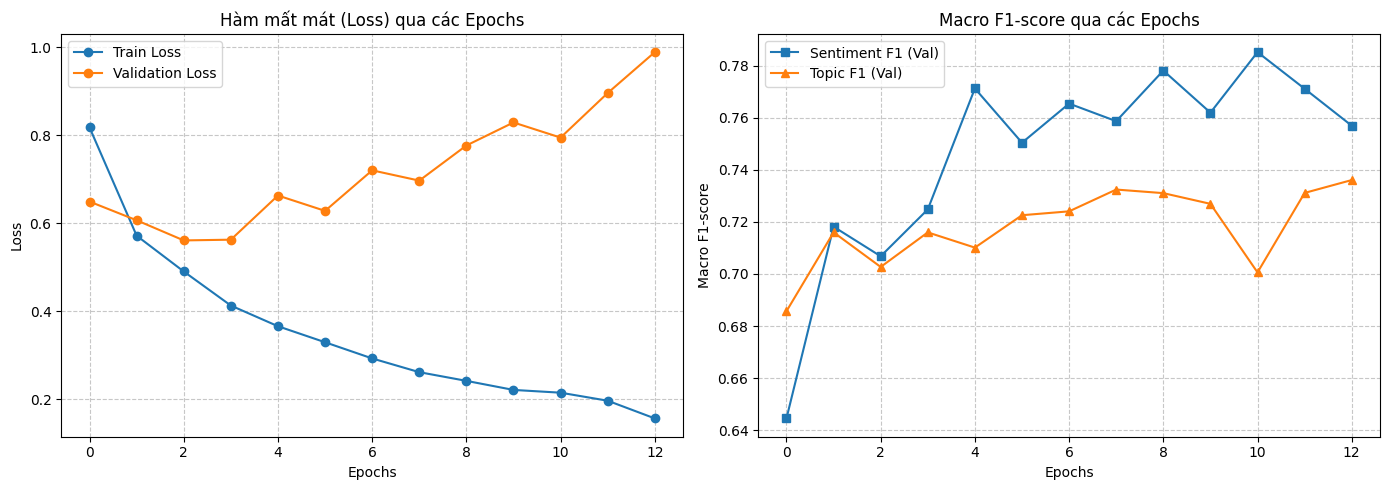

In [9]:
# 1. Vẽ Learning Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Hàm mất mát (Loss) qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history['val_sent_f1'], label='Sentiment F1 (Val)', marker='s')
plt.plot(history['val_topic_f1'], label='Topic F1 (Val)', marker='^')
plt.title('Macro F1-score qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Macro F1-score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 🔍 Insight 5: Phân tích Learning Curves

**Những dấu hiệu cần quan sát trên biểu đồ:**
- **Train Loss giảm đều, Val Loss đi kèm:** Mô hình học tốt, không bị underfitting.
- **Val Loss bắt đầu tăng trong khi Train Loss vẫn giảm:** Dấu hiệu overfitting — Early Stopping sẽ kích hoạt tại đây.
- **F1-score của Topic thường cao hơn Sentiment:** Do phân bố Topic ít mất cân bằng hơn (4 nhãn), trong khi Sentiment bị áp đảo bởi nhãn `Neutral` cực kỳ hiếm.
- **Nếu F1 dao động mạnh giữa các epoch:** Có thể giảm learning rate hoặc tăng batch size để ổn định gradient.


In [10]:
# Tải mô hình tốt nhất để Đánh giá trên tập TEST
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
test_loss, test_sent_f1, test_topic_f1, (s_preds, s_trues, t_preds, t_trues) = evaluate(model, test_loader)

SENTIMENT_NAMES = ['Negative', 'Neutral', 'Positive']
TOPIC_NAMES = ['Lecturer', 'Curriculum', 'Facility', 'Others']

print("\n" + "="*50)
print(" BÁO CÁO KẾT QUẢ CẢM XÚC (SENTIMENT) TRÊN TẬP TEST")
print("="*50)
print(classification_report(s_trues, s_preds, target_names=SENTIMENT_NAMES, digits=4))

print("\n" + "="*50)
print(" BÁO CÁO KẾT QUẢ CHỦ ĐỀ (TOPIC) TRÊN TẬP TEST")
print("="*50)
print(classification_report(t_trues, t_preds, target_names=TOPIC_NAMES, digits=4))


 BÁO CÁO KẾT QUẢ CẢM XÚC (SENTIMENT) TRÊN TẬP TEST
              precision    recall  f1-score   support

    Negative     0.9002    0.9155    0.9078      1409
     Neutral     0.3612    0.4910    0.4162       167
    Positive     0.9456    0.8956    0.9199      1590

    accuracy                         0.8831      3166
   macro avg     0.7357    0.7674    0.7480      3166
weighted avg     0.8946    0.8831    0.8880      3166


 BÁO CÁO KẾT QUẢ CHỦ ĐỀ (TOPIC) TRÊN TẬP TEST
              precision    recall  f1-score   support

    Lecturer     0.9563    0.8594    0.9052      2290
  Curriculum     0.6691    0.7920    0.7254       572
    Facility     0.8293    0.9379    0.8803       145
      Others     0.3521    0.5912    0.4413       159

    accuracy                         0.8373      3166
   macro avg     0.7017    0.7951    0.7380      3166
weighted avg     0.8682    0.8373    0.8483      3166



### 🔍 Insight 6: Phân tích Kết quả Mô hình

**Sentiment Analysis:**
- Nhãn `Neutral` thường có F1 thấp nhất do dữ liệu cực kỳ thiếu (~4%). Dù đã dùng class weights, sự thiếu hụt mẫu huấn luyện vẫn hạn chế khả năng học pattern của nhãn này.
- `Negative` và `Positive` thường đạt F1 cao hơn vì có đặc trưng ngôn ngữ rõ ràng hơn (từ cảm xúc mạnh).

**Topic Classification:**
- `Lecturer` dễ phân loại nhất (chiếm 71% dữ liệu, nhiều mẫu học).
- `Facility` thường khó nhất vì ít mẫu và ngôn ngữ đôi khi trùng lặp với `Others`.

**So sánh với Baseline:**
- Multi-task learning kỳ vọng cải thiện ~2-5% Macro F1 so với 2 mô hình đơn tác vụ riêng lẻ.
- Masked Attention giúp cải thiện đặc biệt rõ ở các câu ngắn (nhiều padding) — phổ biến trong phản hồi sinh viên.


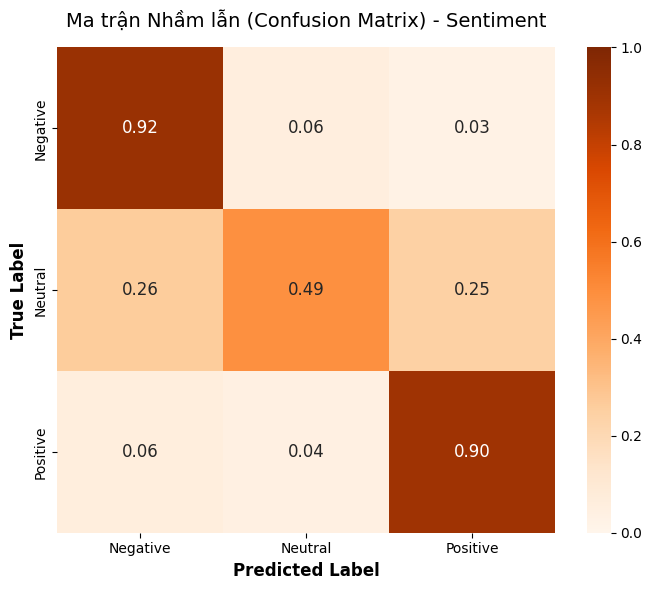

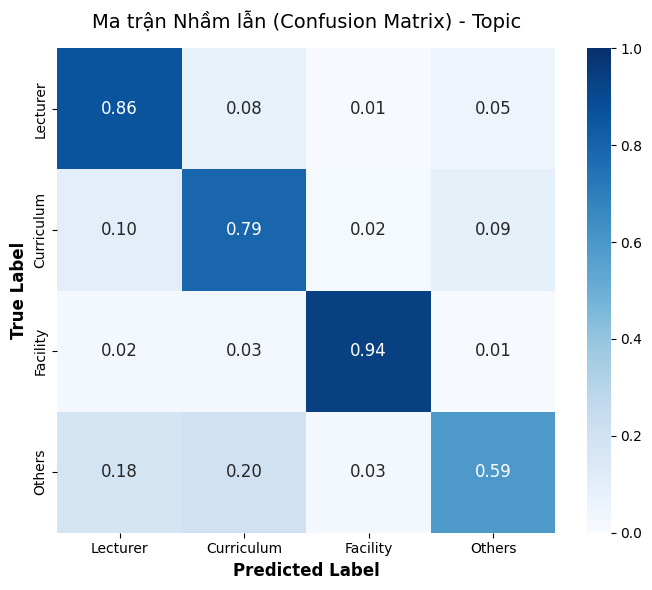

In [11]:
# 2. Vẽ Confusion Matrix phân tích lỗi (Bắt buộc cho slide)
def plot_confusion_matrix(trues, preds, classes, title, cmap='Blues'):
    cm = confusion_matrix(trues, preds)
    # Tính tỷ lệ phần trăm theo từng hàng (True Label)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap=cmap, 
                xticklabels=classes, yticklabels=classes, 
                annot_kws={"size": 12}, vmin=0, vmax=1)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(s_trues, s_preds, SENTIMENT_NAMES, 'Ma trận Nhầm lẫn (Confusion Matrix) - Sentiment', cmap='Oranges')
plot_confusion_matrix(t_trues, t_preds, TOPIC_NAMES, 'Ma trận Nhầm lẫn (Confusion Matrix) - Topic', cmap='Blues')

### 🔍 Insight 7: Phân tích Ma trận Nhầm lẫn

**Sentiment Confusion Matrix:**
- **Điểm yếu chính:** `Neutral` thường bị phân loại nhầm thành `Positive` hoặc `Negative`. Điều này hợp lý vì ranh giới giữa "trung lập" và các cảm xúc yếu thường mờ nhạt trong ngôn ngữ tự nhiên.
- Nếu ô `Neutral → Positive` lớn: Mô hình có xu hướng tích cực hóa các câu trung tính — cần xem lại augmentation hoặc threshold.

**Topic Confusion Matrix:**
- **Nhầm lẫn phổ biến:** `Others` thường bị nhầm với `Curriculum` hoặc `Lecturer` do ngôn ngữ trong câu không đặc thù cho một chủ đề cụ thể.
- `Facility` ↔ `Others`: Phản hồi về cơ sở vật chất đôi khi được sinh viên diễn đạt chung chung, thiếu từ khóa rõ ràng.

**Hướng cải tiến:**
- Tăng dữ liệu cho nhãn thiểu số bằng **data augmentation** (back-translation, paraphrase).
- Thử nghiệm **PhoBERT** thay thế Bi-LSTM để tận dụng ngữ cảnh sâu hơn từ pre-trained transformer tiếng Việt.
- Điều chỉnh ngưỡng quyết định (decision threshold) riêng cho nhãn `Neutral` và `Facility`.
